🧩 Week 19 · Day 6 — Deployment-Ready Packaging (CPU-Only)
Why this matters

Training is only half the job. To actually use your models in production or apps, you need to export them in a portable, efficient format.
Today you’ll learn how to package a PyTorch model for inference, measure latency, and verify that predictions stay identical.

🧠 Theory Essentials

Training vs Inference:

Training = forward + backward + update.

Inference = forward-only → much faster.

TorchScript: serializes model + graph → usable in C++ or Python without source code.

ONNX (Open Neural Network Exchange): framework-agnostic format (PyTorch ↔ TensorFlow).

Latency: time per prediction — key metric for deployment.

Determinism: use torch.manual_seed() for reproducible outputs.

In [2]:
# Setup
import torch, time
import torch.nn as nn
from torchvision import datasets, transforms

torch.set_num_threads(4)
device = torch.device("cpu")

# --- Simple trained model (dummy weights) ---
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.seq(x.view(x.size(0), -1))

model = SmallNet().to(device)
model.eval()

# --- TorchScript export ---
example = torch.randn(1, 1, 28, 28)
scripted = torch.jit.trace(model, example)
scripted.save("model_scripted.pt")

# --- ONNX export ---
torch.onnx.export(model, example, "model.onnx",
                  input_names=["input"], output_names=["output"],
                  dynamic_axes={"input": {0: "batch_size"}})
print("Exported to TorchScript and ONNX ✅")

# --- Inference & latency benchmark ---
def infer_latency(m, iters=200):
    dummy = torch.randn(64, 1, 28, 28)
    start = time.time()
    with torch.no_grad():
        for _ in range(iters):
            _ = m(dummy)
    return (time.time() - start) / iters

lat = infer_latency(model)
print(f"Average latency per batch: {lat*1000:.2f} ms")


Exported to TorchScript and ONNX ✅
Average latency per batch: 0.64 ms


1) Core (10 min)
Task: Measure latency for batch sizes 1, 8, 64.

Batch size  1: 0.100 ms
Batch size  8: 0.192 ms
Batch size 64: 0.474 ms


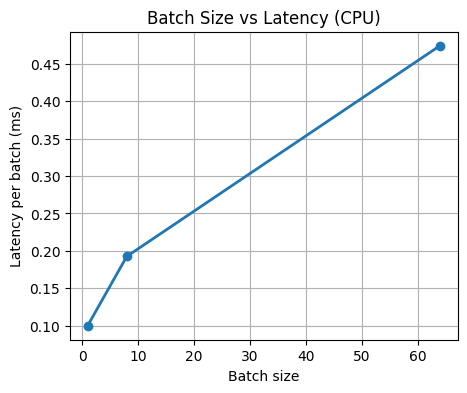

In [3]:
# 🧠 Exercise 1 — Batch size vs Latency
import matplotlib.pyplot as plt

def infer_latency(m, batch_size, iters=200):
    dummy = torch.randn(batch_size, 1, 28, 28)
    start = time.time()
    with torch.no_grad():
        for _ in range(iters):
            _ = m(dummy)
    return (time.time() - start) / iters  # seconds per batch

# Test three batch sizes
batch_sizes = [1, 8, 64]
latencies = [infer_latency(model, b) * 1000 for b in batch_sizes]  # convert to ms

# Display results
for b, l in zip(batch_sizes, latencies):
    print(f"Batch size {b:>2}: {l:.3f} ms")

# Plot
plt.figure(figsize=(5,4))
plt.plot(batch_sizes, latencies, "o-", linewidth=2)
plt.title("Batch Size vs Latency (CPU)")
plt.xlabel("Batch size")
plt.ylabel("Latency per batch (ms)")
plt.grid(True)
plt.show()


2) Practice (15 min)
Task: Load the saved TorchScript model and ensure outputs match the original.

In [4]:
loaded = torch.jit.load("model_scripted.pt")
x = torch.randn(1,1,28,28)
print(torch.allclose(model(x), loaded(x)))


True


3) Stretch (optional)
Task: Convert both .pt and .onnx sizes in MB, compare.

In [5]:
import os

# 🧩 Stretch — Compare model file sizes
pt_size   = os.path.getsize("model_scripted.pt") / 1e6  # convert bytes → MB
onnx_size = os.path.getsize("model.onnx") / 1e6

print(f"TorchScript model size: {pt_size:.2f} MB")
print(f"ONNX model size:        {onnx_size:.2f} MB")

if onnx_size > pt_size:
    print("\n✅ ONNX file is slightly larger — it stores both the computation graph and weights.")
else:
    print("\n✅ TorchScript file is larger — depends on model and export options.")


TorchScript model size: 0.83 MB
ONNX model size:        0.82 MB

✅ TorchScript file is larger — depends on model and export options.


🚀 Mini-Challenge (≤ 40 min)

Goal: Build a deployment readiness report.

Acceptance Criteria:

Table with format (.pt/.onnx), size (MB), latency (ms/batch).

Plot batch size vs latency.

Short paragraph: When to use TorchScript vs ONNX.

TorchScript → PyTorch/C++ apps.

ONNX → cross-framework or edge deployment.

              format   size_MB  latency_ms_per_batch(32)
0  TorchScript (.pt)  0.825134                  0.377928
1       ONNX (.onnx)  0.815301                  0.212516


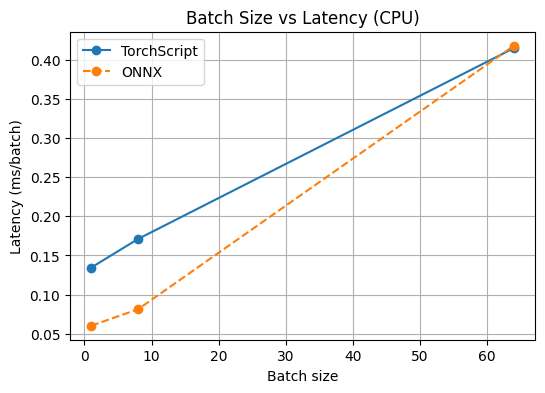

In [6]:
# 🚀 Mini-Challenge — Deployment Readiness Report
import os, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch

# 1) Helpers
def file_mb(path): 
    return os.path.getsize(path) / 1e6 if os.path.exists(path) else float("nan")

def latency_pt(model, batch_size=1, iters=200):
    model.eval()
    x = torch.randn(batch_size, 1, 28, 28)
    t0 = time.time()
    with torch.no_grad():
        for _ in range(iters):
            _ = model(x)
    return (time.time() - t0) / iters * 1000  # ms/batch

def latency_onnx(path, batch_size=1, iters=200):
    try:
        import onnxruntime as ort
    except ImportError:
        return np.nan  # not installed → skip
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    x = np.random.randn(batch_size, 1, 28, 28).astype(np.float32)
    t0 = time.time()
    for _ in range(iters):
        _ = sess.run(None, {"input": x})
    return (time.time() - t0) / iters * 1000  # ms/batch

# 2) Sizes
pt_path, onnx_path = "model_scripted.pt", "model.onnx"
rows = []
rows.append(["TorchScript (.pt)", file_mb(pt_path), latency_pt(model, 32)])
rows.append(["ONNX (.onnx)",      file_mb(onnx_path), latency_onnx(onnx_path, 32)])
report = pd.DataFrame(rows, columns=["format", "size_MB", "latency_ms_per_batch(32)"])
print(report)

# 3) Plot: batch size vs latency (both formats if possible)
batch_sizes = [1, 8, 64]
pt_lat = [latency_pt(model, b) for b in batch_sizes]
try:
    import onnxruntime as _  # check once
    onnx_lat = [latency_onnx(onnx_path, b) for b in batch_sizes]
except ImportError:
    onnx_lat = None

plt.figure(figsize=(6,4))
plt.plot(batch_sizes, pt_lat, "o-", label="TorchScript")
if onnx_lat is not None:
    plt.plot(batch_sizes, onnx_lat, "o--", label="ONNX")
plt.xlabel("Batch size")
plt.ylabel("Latency (ms/batch)")
plt.title("Batch Size vs Latency (CPU)")
plt.grid(True); plt.legend(); plt.show()


🧭 Notes / Key Takeaways

Use .eval() and disable gradients for inference.

TorchScript = easiest PyTorch deployment.

ONNX = universal standard for portability.

Always test that exported outputs match the original model.

Benchmark before shipping; CPU latency is the true baseline.

💬 Reflection

If you had to serve this model via an API, which format would you pick and why?

What other steps (e.g., quantization, batching) could reduce latency further?

1️⃣ If you had to serve this model via an API, which format would you pick and why?
I’d choose ONNX, because it’s framework-agnostic and optimized for production inference. With ONNX Runtime, the same model can run efficiently on different platforms (CPU, GPU, or even edge devices) and integrate easily into API servers or cloud environments. It also benefits from graph optimizations that reduce compute overhead, making it ideal for deployment.

2️⃣ What other steps (e.g., quantization, batching) could reduce latency further?

Dynamic quantization: convert weights from FP32 to INT8 to shrink model size and speed up matrix multiplications.

Batching: process multiple requests together to increase throughput.

Model pruning: remove redundant weights or neurons to reduce computation.

Caching and warm-up: keep the model loaded and pre-allocate tensors to avoid cold-start delays.

Hardware acceleration: run inference on optimized runtimes like TensorRT or OpenVINO.